# Facial Dynamics During Multitasking - MATB

In [ ]:
import json
import random
from pathlib import Path

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
import notebook_utils as nb_utils  # noqa: F401

# Define the root path of the project to locate artifacts
ROOT = Path.cwd().parents[1]
ingest_dir = ROOT / "artifacts" / "ingest" / "matb"
pose_path = ingest_dir / "pose.parquet"
# Load the ingested data from the Parquet file
df = pd.read_parquet(pose_path)

## Ingest
First we will verify that the ingest step worked as expected. We will print the number of "trials" (csvs) ingested and also plot the keypoints. Each time you rerun the cell a new random frame is plotted.

Found 3 trials in the ingested data.


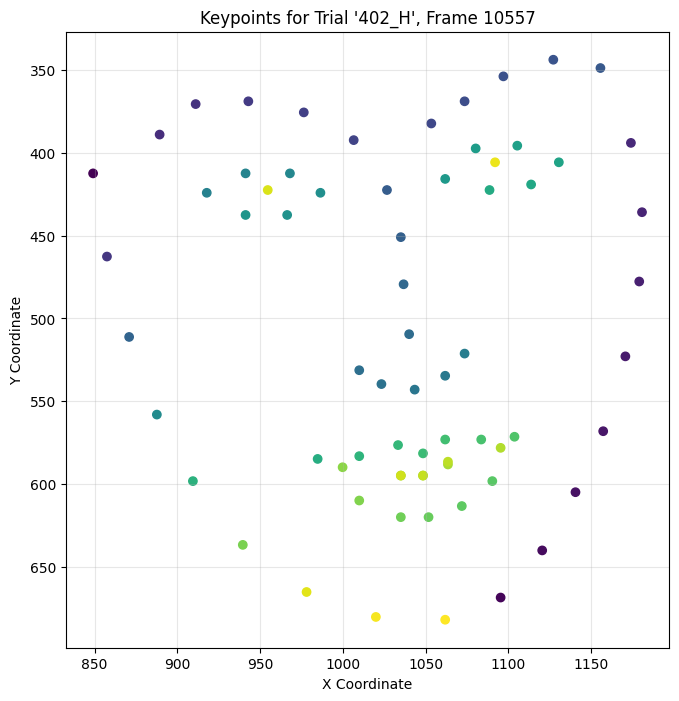

In [14]:
# Print number of trials
n_trials = df["trial_id"].nunique()
print(f"Found {n_trials} trials in the ingested data.")

# Create a figure of keypoints from a random frame in the first trial
trial_ids = df["trial_id"].unique()
selected_trial_id = trial_ids[0]
trial_df = df[df["trial_id"] == selected_trial_id].copy()
frame_ids = trial_df["frame"].unique()
random_frame_id = random.choice(frame_ids)
frame_df = trial_df[trial_df["frame"] == random_frame_id]
fig, ax = plt.subplots(figsize=(8, 8))
colors = cm.viridis(np.linspace(0, 1, len(frame_df)))
ax.scatter(frame_df["x"], frame_df["y"], c=colors)
ax.invert_yaxis()  # Invert y-axis because image coordinates start from the top-left
ax.set_title(f"Keypoints for Trial '{selected_trial_id}', Frame {random_frame_id}")
ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.3)

plt.show()

## Preprocessing

### Extract a Subset of Keypoints
Instead of preprocessing all 70 keypoints from openpose we will select relevant ones that are used in the downstream analysis. Specifically we will focus on the pupils, temples, and four stable landmarks for the Procrustes transofmration (nose tip (30), side of nose (31), top right eyelid (37), bottom left eyelid (46)) 

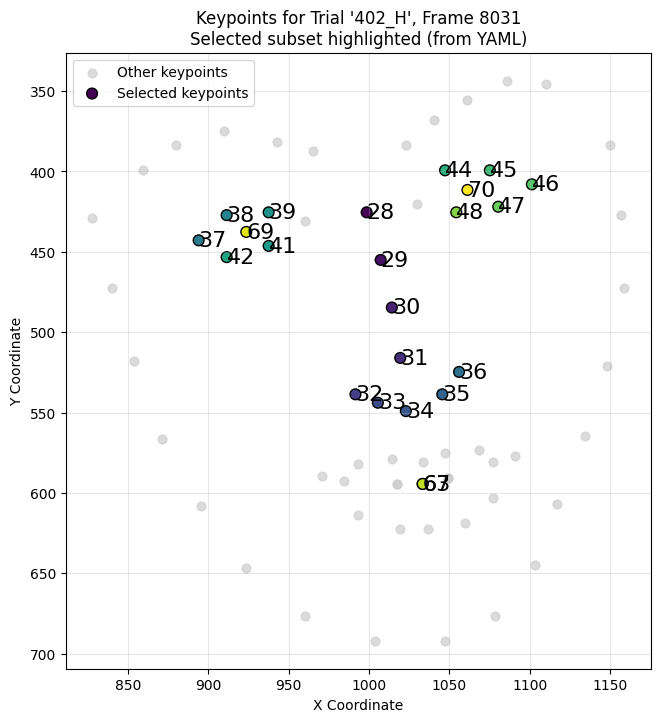

In [15]:
# Load keypoints from preprocess.yaml
cfg_path = ROOT / "examples" / "case_study_1_matb" / "configs" / "preprocess.yaml"
with open(cfg_path, "r") as f:
    cfg = yaml.safe_load(f)
selected_keypoints = cfg["preprocess"]["selection"]["keypoints"]

# Use the same trial and random frame as before
trial_ids = df["trial_id"].unique()
selected_trial_id = trial_ids[0]
trial_df = df[df["trial_id"] == selected_trial_id].copy()
frame_ids = trial_df["frame"].unique()
random_frame_id = random.choice(frame_ids)
frame_df = trial_df[trial_df["frame"] == random_frame_id]

# Split into selected and non-selected keypoints
selected_mask = frame_df["keypoint"].isin(selected_keypoints)
selected_df = frame_df[selected_mask]
other_df = frame_df[~selected_mask]

fig, ax = plt.subplots(figsize=(8, 8))
if not other_df.empty:
    ax.scatter(
        other_df["x"],
        other_df["y"],
        c="#cccccc",
        s=40,
        label="Other keypoints",
        alpha=0.7,
    )
if not selected_df.empty:
    colors = cm.viridis(np.linspace(0, 1, len(selected_df)))
    ax.scatter(
        selected_df["x"],
        selected_df["y"],
        c=colors,
        s=60,
        label="Selected keypoints",
        edgecolor="k",
    )

for idx, row in selected_df.iterrows():
    ax.text(
        row["x"],
        row["y"],
        str(row["keypoint"]),
        fontsize=16,
        color="black",
        ha="left",
        va="center",
    )

ax.invert_yaxis()
ax.set_title(
    f"Keypoints for Trial '{selected_trial_id}', Frame {random_frame_id}\nSelected subset highlighted (from YAML)"
)
ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.show()

### Window & Interpolation
The next step is to define window lengths and perform quality control. For this dataset we used windows of 60 seconds with 50% overlap. The max interpolation was set to 1 second. This means if the confidence was below the threshold (0.30) for more than 1 second the window was excluded. We will also print how many total frames were interpolated

In [16]:
# Load QC and provenance artifacts
preprocess_dir = ROOT / "artifacts" / "preprocess" / "matb"
qc_path = preprocess_dir / "qc_preprocess.json"
prov_path = preprocess_dir / "provenance.json"

with open(qc_path, "r") as f:
    qc_data = json.load(f)

with open(prov_path, "r") as f:
    prov_data = json.load(f)

# Extract parameters from the config within the provenance file
cfg = prov_data["config"]
conf_min = cfg["confidence"]["conf_min"]
max_gap_frames = cfg["missing"]["interpolation"]["limit"]["max_gap_frames"]
window_length = cfg["windowing"]["length_s"]
window_step = cfg["windowing"]["step_s"]
n_dropped = qc_data["summary"]["n_dropped"]

# Calculate interpolated frames
# 1. Load the raw data and apply selection/confidence filters to get pre-interpolation state
pre_df = pd.read_parquet(pose_path)
pre_df = pre_df[pre_df["keypoint"].isin(selected_keypoints)]
pre_df = pre_df[pre_df["conf"] >= conf_min]
nans_before = pre_df[["x", "y"]].isna().sum().sum()

# 2. Load the cleaned data (which has been interpolated)
clean_df = pd.read_parquet(preprocess_dir / "pose_clean.parquet")
nans_after = clean_df[["x", "y"]].isna().sum().sum()

# 3. The number of interpolated values is the reduction in NaNs
total_interpolated = nans_before - nans_after

print("--- Preprocessing Parameters ---")
print(f"Confidence Threshold: {conf_min}")
print(f"Max Interpolation Gap: {max_gap_frames} frames")
print(f"Window Length: {window_length} seconds")
print(f"Window Step: {window_step} seconds")
print("--- QC Results ---")
print(f"Number of Windows Dropped: {n_dropped}")
print(f"Total Interpolated Values (x, y): {total_interpolated:,}")

--- Preprocessing Parameters ---
Confidence Threshold: 0.3
Max Interpolation Gap: 60 frames
Window Length: 60.0 seconds
Window Step: 30.0 seconds
--- QC Results ---
Number of Windows Dropped: 0
Total Interpolated Values (x, y): 0


### Butterworth Filter

--- Filter Configuration ---
Lowpass Filter: Enabled
Cutoff Frequency: 10.0 Hz
Order: 4


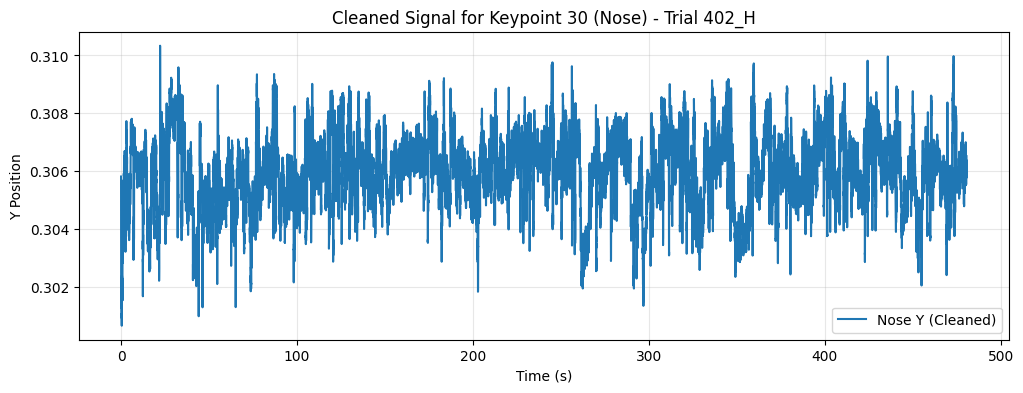

In [17]:
# Extract filter settings from provenance
filter_cfg = prov_data["config"]["detrend_filter"]
print("--- Filter Configuration ---")
if filter_cfg["lowpass"]["enabled"]:
    print("Lowpass Filter: Enabled")
    print(f"Cutoff Frequency: {filter_cfg['lowpass']['cutoff_hz']} Hz")
    print(f"Order: {filter_cfg['lowpass']['order']}")
else:
    print("Lowpass Filter: Disabled")

# Plot a sample of the cleaned (filtered & aligned) signal
# using the clean_df loaded in the previous step
trial_clean = clean_df[clean_df["trial_id"] == selected_trial_id]
kp_clean = trial_clean[trial_clean["keypoint"] == "30"]  # Nose tip

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(kp_clean["time"], kp_clean["y"], label="Nose Y (Cleaned)")
ax.set_title(f"Cleaned Signal for Keypoint 30 (Nose) - Trial {selected_trial_id}")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Y Position")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

### Procrustes Transformation

Loaded alignment transforms for 3 trials.


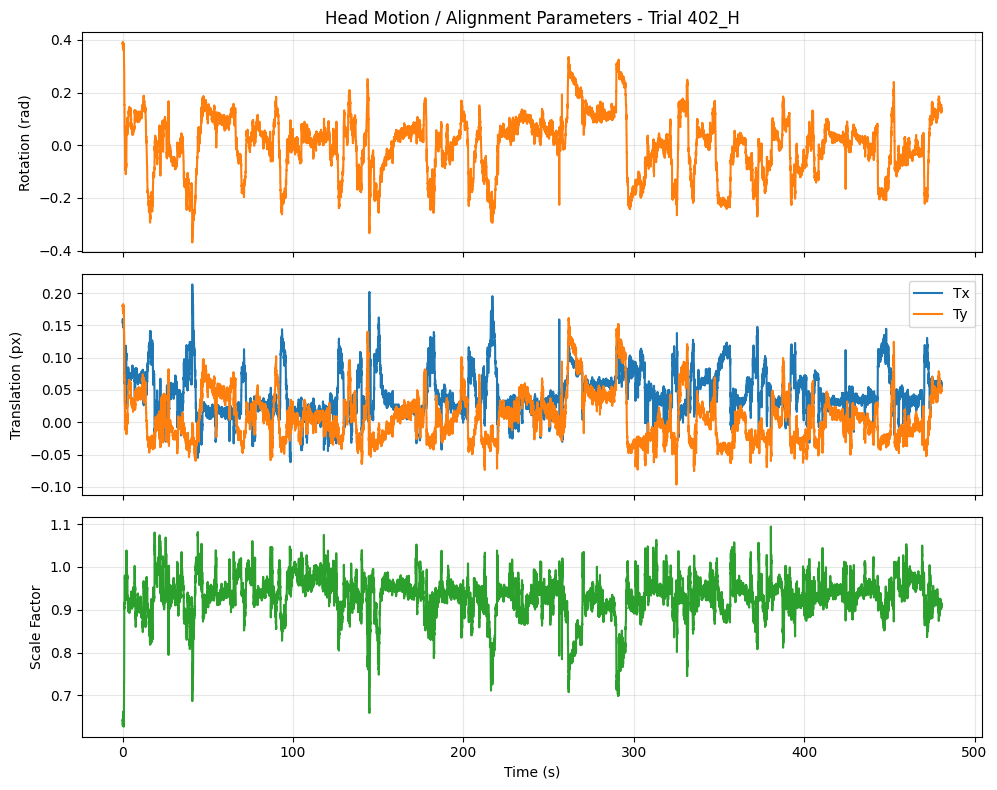

In [18]:
# Load alignment transforms
transforms_path = preprocess_dir / "alignment_transforms.parquet"
transforms_df = pd.read_parquet(transforms_path)

# Filter for the selected trial
trial_transforms = transforms_df[
    transforms_df["trial_id"] == selected_trial_id
].sort_values("time")

print(
    f"Loaded alignment transforms for {len(transforms_df['trial_id'].unique())} trials."
)

# Plot head motion parameters
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Rotation
axes[0].plot(
    trial_transforms["time"], trial_transforms["rotation_angle"], color="tab:orange"
)
axes[0].set_ylabel("Rotation (rad)")
axes[0].set_title(f"Head Motion / Alignment Parameters - Trial {selected_trial_id}")
axes[0].grid(True, alpha=0.3)

# Translation
axes[1].plot(trial_transforms["time"], trial_transforms["translation_x"], label="Tx")
axes[1].plot(trial_transforms["time"], trial_transforms["translation_y"], label="Ty")
axes[1].set_ylabel("Translation (px)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Scale
axes[2].plot(trial_transforms["time"], trial_transforms["scale"], color="tab:green")
axes[2].set_ylabel("Scale Factor")
axes[2].set_xlabel("Time (s)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Linear Analysis / Features

### Compute derived signals

In addition to some of the keypoints we also derived a few measures including blink (distance between eyelids) and mouth opening (distance between lip keypoints). For all measures (including keypoints) we will also calculate velocity and acceleration. We will save summary statistics for these features in each window.

In [19]:
# Load extracted features
features_dir = ROOT / "artifacts" / "features" / "matb"
features_path = features_dir / "features.parquet"
features_csv_path = features_dir / "features.csv"

# Load feature config to see what was extracted
feat_prov_path = features_dir / "provenance_features.json"
with open(feat_prov_path, "r") as f:
    feat_prov = json.load(f)

print("Extracted Features")
print(f"Facial: {feat_prov['config']['facial']['enabled']}")
print(f"Head Motion: {feat_prov['config']['head_motion']['enabled']}")
print(f"Kinematics: {feat_prov['config']['kinematics']['enabled']}")

features_df = pd.read_parquet(features_path)
print(f"\nLoaded feature matrix with {len(features_df)} rows.")

print("\nSample Feature Data:")
print(features_df.head(10))

# List unique features for inspection
print("\nUnique Features Extracted:")
unique_feats = sorted(features_df["feature"].unique())
# Print first 10 and last 5 to avoid clutter
print(f"{unique_feats[:10]} ... {unique_feats[-5:]}")

Extracted Features
Facial: True
Head Motion: True
Kinematics: True

Loaded feature matrix with 9720 rows.

Sample Feature Data:
  trial_id    window_id keypoint     feature     value
0    402_H  402_H_w0000       30  speed_mean  0.019336
1    402_H  402_H_w0000       30   speed_std  0.022147
2    402_H  402_H_w0000       30   speed_rms  0.029400
3    402_H  402_H_w0000       30  accel_mean  1.946275
4    402_H  402_H_w0000       30   accel_std  1.729910
5    402_H  402_H_w0000       30   accel_rms  2.603954
6    402_H  402_H_w0000       31  speed_mean  0.023448
7    402_H  402_H_w0000       31   speed_std  0.029482
8    402_H  402_H_w0000       31   speed_rms  0.037670
9    402_H  402_H_w0000       31  accel_mean  2.336587

Unique Features Extracted:
['accel_mean', 'accel_rms', 'accel_std', 'blink_aperture_acc_mean', 'blink_aperture_acc_rms', 'blink_aperture_mean', 'blink_aperture_rms', 'blink_aperture_vel_mean', 'blink_aperture_vel_rms', 'center_face_magnitude_acc_mean'] ... ['pupil_r

### Stats/Figures

In [26]:
# Stats for linear features (per-window)
import numpy as np
from notebook_utils import build_table_with_emmeans

# 1. Prepare metadata columns
features_df["participant"] = features_df["trial_id"].astype(str).str.split("_").str[0]
features_df["condition"] = features_df["trial_id"].astype(str).str.split("_").str[1]
features_df["window_index"] = (
    features_df["window_id"].astype(str).str.split("_w").str[-1].astype(int)
)

# 2. Pivot to wide format expected by build_table_with_emmeans
features_df["col_name"] = features_df.apply(
    lambda r: f"{r['keypoint']}_{r['feature']}"
    if r["keypoint"] not in ["composite", "pairwise", "head_motion"]
    else r["feature"],
    axis=1,
)
wide_df = features_df.pivot_table(
    index=["trial_id", "window_id", "participant", "condition", "window_index"],
    columns="col_name",
    values="value",
).reset_index()

# 2b. Drop degenerate metrics (all-NaN, zero variance, or single unique value)
numeric_cols = [
    c
    for c in wide_df.columns
    if c not in ["trial_id", "window_id", "participant", "condition", "window_index"]
]
keep = []
for c in numeric_cols:
    ser = pd.to_numeric(wide_df[c], errors="coerce")
    if ser.notna().sum() < 3:
        print(f"[drop metric] {c}: <3 non-NA values")
        continue
    if ser.nunique(dropna=True) <= 1:
        print(f"[drop metric] {c}: single unique value")
        continue
    if ser.std(skipna=True) == 0:
        print(f"[drop metric] {c}: zero variance")
        continue
    keep.append(c)
wide_df_filt = wide_df[
    ["trial_id", "window_id", "participant", "condition", "window_index"] + keep
]

# 3. Run mixed-model stats and export LaTeX + figures
stats_out_dir = ROOT / "examples" / "case_study_1_matb" / "stats_output"
stats_tex_path = stats_out_dir / "linear_stats.tex"
figs_out_dir = stats_out_dir / "figures"

print(
    f"Running linear stats on {len(wide_df_filt)} windows... conditions={wide_df_filt['condition'].unique()}"
)
modeled, skipped = build_table_with_emmeans(wide_df_filt, stats_tex_path, figs_out_dir)
print(f"Linear stats complete. Modeled: {modeled}, Skipped: {skipped}")
print(f"LaTeX table: {stats_tex_path}\nFigures: {figs_out_dir}")

Running linear stats on 45 windows... conditions=['H' 'L' 'M']
[OK] wrote /Users/cartersale/Research/Projects/pose-dynamics/examples/case_study_1_matb/stats_output/linear_stats_disp.tex
[OK] wrote /Users/cartersale/Research/Projects/pose-dynamics/examples/case_study_1_matb/stats_output/linear_stats_vel.tex
[OK] wrote /Users/cartersale/Research/Projects/pose-dynamics/examples/case_study_1_matb/stats_output/linear_stats_acc.tex
[DONE] modeled=216, skipped=0
Linear stats complete. Modeled: 216, Skipped: 0
LaTeX table: /Users/cartersale/Research/Projects/pose-dynamics/examples/case_study_1_matb/stats_output/linear_stats.tex
Figures: /Users/cartersale/Research/Projects/pose-dynamics/examples/case_study_1_matb/stats_output/figures


## RQA / CRQA

### Average Mutual Information & False Nearest Neighbors

Processing time series: 100%|██████████| 3/3 [00:00<00:00,  4.84it/s]


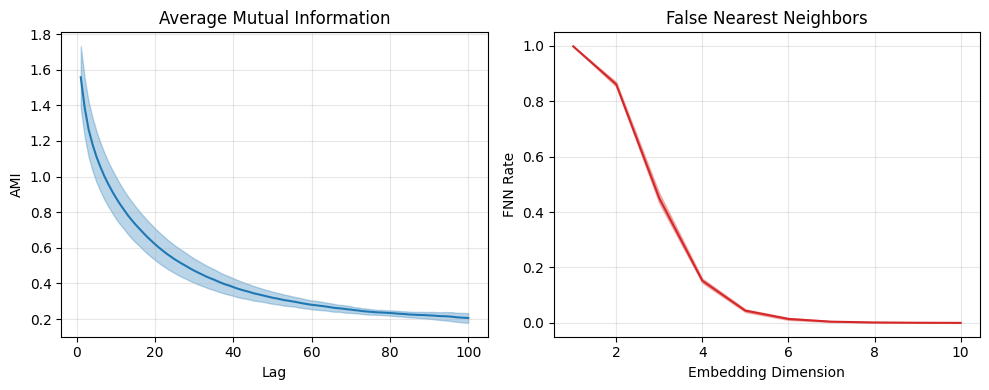

In [ ]:
# 1. Filter time series (nose y-coordinate)
nose_y_df = clean_df[clean_df["keypoint"] == "30"].copy()

# 2. Run AMI/FNN on 20 random windows
ami_fnn_results = nb_utils.run_ami_fnn_on_random_timeseries(  # noqa: F405
    nose_y_df,
    value_col="x",  # Use 'x' or 'y' depending on which coordinate you want to analyze
    n_series=10,  # number of series to sample for AMI/FNN (adjust as needed)
    max_lag=100,  # maximum lag to compute AMI
    ami_bins=32,
    max_dim=10,  # maximum embedding dimension for FNN
    tau=20,  # time delay for FNN
    rtol=10.0,
    atol=2.0,
    min_length=100,
    random_state=42,
)

# 3. Plot mean pm std band for AMI and FNN
fig, (ax_ami, ax_fnn) = nb_utils.plot_ami_fnn_curves(ami_fnn_results)  # noqa: F405
plt.show()

### Compute (C)RQA

In [27]:
# Load RQA/CRQA outputs and prepare wide table
rqa_root = ROOT / "artifacts" / "rqa" / "matb"
records = []
for stats_path in sorted(rqa_root.glob("*/rqa_stats.csv")):
    analysis = stats_path.parent.name
    df_rqa = pd.read_csv(stats_path)
    if df_rqa.empty:
        continue
    df_rqa["analysis"] = analysis
    df_rqa["participant"] = df_rqa["trial_id"].astype(str).str.split("_").str[0]
    df_rqa["condition"] = df_rqa["trial_id"].astype(str).str.split("_").str[1]
    df_rqa["window_index"] = (
        df_rqa["window_id"].astype(str).str.split("_w").str[-1].astype(int)
    )
    records.append(df_rqa)

if not records:
    wide_rqa_df = pd.DataFrame()
    print("No RQA stats found. Run `python run.py rqa --force-rqa` first.")
else:
    rqa_df = pd.concat(records, ignore_index=True)
    metric_cols = [
        c
        for c in rqa_df.columns
        if c
        not in [
            "trial_id",
            "window_id",
            "analysis",
            "participant",
            "condition",
            "window_index",
            "epsilon",
        ]
    ]
    rqa_melt = rqa_df.melt(
        id_vars=[
            "trial_id",
            "window_id",
            "participant",
            "condition",
            "window_index",
            "analysis",
        ],
        value_vars=metric_cols,
        var_name="metric",
        value_name="value",
    )
    rqa_melt["col_name"] = rqa_melt.apply(
        lambda r: f"{r['analysis']}_{r['metric']}", axis=1
    )
    wide_rqa_df = rqa_melt.pivot_table(
        index=["trial_id", "window_id", "participant", "condition", "window_index"],
        columns="col_name",
        values="value",
    ).reset_index()
    print(
        f"Loaded RQA stats from {len(records)} analyses; wide shape={wide_rqa_df.shape}"
    )

Loaded RQA stats from 15 analyses; wide shape=(45, 305)


### Stats/Figures

In [ ]:
# Stats for RQA/CRQA metrics
if wide_rqa_df.empty:
    print("No RQA stats available to model.")
else:
    # Drop degenerate metrics to avoid singular/PD errors in mixed models
    numeric_cols = [
        c
        for c in wide_rqa_df.columns
        if c
        not in ["trial_id", "window_id", "participant", "condition", "window_index"]
    ]
    keep = []
    for c in numeric_cols:
        ser = pd.to_numeric(wide_rqa_df[c], errors="coerce")
        if ser.notna().sum() < 3:
            print(f"[drop metric] {c}: <3 non-NA values")
            continue
        if ser.nunique(dropna=True) <= 1:
            print(f"[drop metric] {c}: single unique value")
            continue
        if ser.std(skipna=True) == 0:
            print(f"[drop metric] {c}: zero variance")
            continue
        keep.append(c)
    wide_rqa_filt = wide_rqa_df[
        ["trial_id", "window_id", "participant", "condition", "window_index"] + keep
    ]

    rqa_stats_out_dir = ROOT / "examples" / "case_study_1_matb" / "stats_output"
    rqa_tex_path = rqa_stats_out_dir / "rqa_stats.tex"
    rqa_figs_dir = rqa_stats_out_dir / "rqa_figures"
    print(
        f"Running RQA stats on {len(wide_rqa_filt)} windows... conditions={wide_rqa_filt['condition'].unique()}"
    )
    modeled_rqa, skipped_rqa = build_table_with_emmeans(
        wide_rqa_filt, rqa_tex_path, rqa_figs_dir
    )
    print(f"RQA stats complete. Modeled: {modeled_rqa}, Skipped: {skipped_rqa}")
    print(f"LaTeX table: {rqa_tex_path}\nFigures: {rqa_figs_dir}")

Running RQA stats on 45 windows... conditions=['H' 'L' 'M']


R callback write-console: Error in .dsy2dpo(.M2sym(from)) : 
  not a positive definite matrix (and positive semidefiniteness is not checked)
  


[skip] crqa_head_motion_pupil_mag_diag_ignore: model error -> Error in .dsy2dpo(.M2sym(from)) : 
  not a positive definite matrix (and positive semidefiniteness is not checked)



R callback write-console: Error in .dsy2dpo(.M2sym(from)) : 
  not a positive definite matrix (and positive semidefiniteness is not checked)
  


[skip] crqa_head_tx_pupil_dx_diag_ignore: model error -> Error in .dsy2dpo(.M2sym(from)) : 
  not a positive definite matrix (and positive semidefiniteness is not checked)



R callback write-console: Error in .dsy2dpo(.M2sym(from)) : 
  not a positive definite matrix (and positive semidefiniteness is not checked)
  


[skip] crqa_head_ty_pupil_dy_diag_ignore: model error -> Error in .dsy2dpo(.M2sym(from)) : 
  not a positive definite matrix (and positive semidefiniteness is not checked)



R callback write-console: Error in .dsy2dpo(.M2sym(from)) : 
  not a positive definite matrix (and positive semidefiniteness is not checked)
  


[skip] crqa_pupil_face_diag_ignore: model error -> Error in .dsy2dpo(.M2sym(from)) : 
  not a positive definite matrix (and positive semidefiniteness is not checked)



Exception ignored from cffi callback <function _processevents at 0x1605d3ec0>:
Traceback (most recent call last):
  File "/Users/cartersale/Research/Projects/pose-dynamics/.venv/lib/python3.13/site-packages/rpy2/rinterface_lib/callbacks.py", line 308, in _processevents
    @ffi_proxy.callback(ffi_proxy._processevents_def,
KeyboardInterrupt: 
